# NB22 — New Signals: Thai Bond Yields, Fund Flow, Put/Call Ratio

Tests three alternative data signals for alpha:

| Signal | Source | Hypothesis |
|--------|--------|-----------|
| **TH yield slope** (10Y–1Y) | Bank of Thailand | Steepening = risk-on → bullish SET |
| **Foreign net flow** (13w cumul) | SET investor type | Sustained foreign buying → momentum |
| **PCR Z-score** (52w rolling) | TFEX SET50 | Extreme put buying = contrarian buy |

Methodology: IC vs 1-week forward SET return, regime analysis, system integration.


## 1. Setup & Data


In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ROOT = Path('..').resolve().parent
RAW  = ROOT / 'data' / 'raw'
DATA = ROOT / 'data' / 'processed'
FIGS = Path('.') / 'figs'
FIGS.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})
WEEKS_PER_YEAR = 52
RF_ANNUAL      = 0.02
TC_ONE_WAY     = 0.001
START          = '2010-01-01'   # all three new sources start ~2010

In [2]:
# Base SET return series from unified_weekly_clean
df_base = pd.read_csv(DATA / 'unified_weekly_clean.csv',
                      index_col=0, parse_dates=True).sort_index()
df_base = df_base.loc[START:]

set_ret  = df_base['SET_index_ret_w']
eem_sig  = df_base['eem_ret_d_lag1']

# Existing US yield slope for comparison (already in the feature set)
us_slope_existing = df_base['yield_curve_slope'] if 'yield_curve_slope' in df_base.columns else None

print(f'Base data: {df_base.shape[0]} weeks  '
      f'{df_base.index[0].date()} -> {df_base.index[-1].date()}')
print(f'SET return — mean: {set_ret.mean()*52:.1%}  std: {set_ret.std()*52**0.5:.1%}')

Base data: 835 weeks  2010-01-01 -> 2025-12-26
SET return — mean: 5.2%  std: 14.4%


## 2. Signal 1 — Thai Yield Curve Slope (10Y – 1Y)

A steep yield curve signals healthy growth expectations → bullish equities.
An inverted curve precedes recessions → bearish.
This is the **Thai domestic** version vs the US slope we already have.


In [3]:
bonds_path = RAW / 'bot_bond_yields.csv'
has_bonds = bonds_path.exists()
print(f'bot_bond_yields.csv exists: {has_bonds}')
if has_bonds:
    bonds = pd.read_csv(bonds_path, parse_dates=['date'])
    bonds = bonds.set_index('date').sort_index()
    print(bonds.tail(3))
    print(f'Columns: {bonds.columns.tolist()}')
    print(f'Rows: {len(bonds)}  '
          f'{bonds.index[0].date()} -> {bonds.index[-1].date()}')

bot_bond_yields.csv exists: False


In [4]:
if has_bonds:
    # Compute slope: 10Y - 1Y  (in percentage points)
    bonds['th_slope'] = bonds['yield_10y'] - bonds['yield_1y']
    bonds['th_slope_chg_4w'] = bonds['th_slope'].diff(4)   # 4-week change in slope

    # Resample to weekly (last observation in week, forward-fill)
    bonds_w = bonds[['th_slope', 'th_slope_chg_4w']].resample('W-FRI').last().ffill()

    print('Thai yield slope (weekly):')
    print(bonds_w.tail(5).to_string())
    print(f'Mean slope: {bonds_w["th_slope"].mean():.2f}pp  '
          f'Std: {bonds_w["th_slope"].std():.2f}pp')

In [5]:
def compute_ic(signal: pd.Series, forward_ret: pd.Series,
               lag: int = 1, label: str = '') -> dict:
    '''
    Information Coefficient (Spearman rank correlation).
    signal is lagged by `lag` weeks before correlating with forward_ret.
    '''
    sig_lagged = signal.shift(lag)
    both = pd.concat([sig_lagged, forward_ret], axis=1).dropna()
    both.columns = ['sig', 'ret']
    r, p = stats.spearmanr(both['sig'], both['ret'])
    n = len(both)
    t = r * np.sqrt(n - 2) / np.sqrt(1 - r**2 + 1e-12)
    stars = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
    print(f'  IC {label:35s}: {r:+.4f}  p={p:.3f} {stars}  n={n}')
    return {'label': label, 'IC': r, 'p': p, 'n': n, 'stars': stars}

ic_results = []

In [6]:
if has_bonds:
    # Align to SET return index
    sig_slope = bonds_w['th_slope'].reindex(set_ret.index).ffill()
    sig_slope_chg = bonds_w['th_slope_chg_4w'].reindex(set_ret.index).ffill()

    print('IC analysis — Thai bond yield signals:')
    ic_results.append(compute_ic(sig_slope,     set_ret, lag=1, label='TH yield slope level (lag1)'))
    ic_results.append(compute_ic(sig_slope_chg, set_ret, lag=1, label='TH yield slope 4w change (lag1)'))
    ic_results.append(compute_ic(sig_slope,     set_ret, lag=2, label='TH yield slope level (lag2)'))
else:
    print('No bond data yet — run: python3 scripts/fetch_bot_bonds.py')
    print('Skipping to next signal...')

No bond data yet — run: python3 scripts/fetch_bot_bonds.py
Skipping to next signal...


In [7]:
if has_bonds:
    # Regime analysis: slope terciles
    sig_slope_lag = sig_slope.shift(1)
    q33 = sig_slope_lag.quantile(0.33)
    q67 = sig_slope_lag.quantile(0.67)

    regime_slope = pd.cut(
        sig_slope_lag,
        bins=[-np.inf, q33, q67, np.inf],
        labels=['Inverted/Flat', 'Normal', 'Steep']
    )

    ret_by_regime = {}
    for label in ['Inverted/Flat', 'Normal', 'Steep']:
        mask = regime_slope == label
        ann  = set_ret[mask].mean() * WEEKS_PER_YEAR
        ret_by_regime[label] = ann
        print(f'  {label:15s}: AnnRet = {ann:+.1%}  n={mask.sum()}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Time series of slope
    bonds_w['th_slope'].plot(ax=axes[0], color='steelblue')
    axes[0].axhline(0, color='red', lw=0.8, ls='--')
    axes[0].set_title('Thai Yield Curve Slope (10Y - 1Y)')
    axes[0].set_ylabel('Percentage points')

    # Regime returns
    labels = list(ret_by_regime.keys())
    values = [ret_by_regime[l] for l in labels]
    colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in values]
    axes[1].bar(labels, values, color=colors, alpha=0.8, edgecolor='white')
    axes[1].set_title('SET Ann. Return by Yield Curve Regime (1w forward, lag1)')
    axes[1].set_ylabel('Annualised return')
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    axes[1].axhline(0, color='black', lw=0.6)

    plt.tight_layout()
    plt.savefig(FIGS / 'nb22_bond_signal.png', bbox_inches='tight')
    plt.show()

## 3. Signal 2 — SET Foreign Fund Flow

**Hypothesis:** Sustained foreign buying (high 13-week cumulative net) drives momentum.
Foreign flow is often informed (macro, global allocation) so it tends to persist.

**Feature:** 13-week rolling sum of foreign net buy, Z-scored (52-week rolling).


In [8]:
flow_path = RAW / 'set_fund_flow.csv'
has_flow = flow_path.exists()
print(f'set_fund_flow.csv exists: {has_flow}')
if has_flow:
    flow = pd.read_csv(flow_path, parse_dates=['date'])
    flow = flow.set_index('date').sort_index()
    print(flow.tail(3).to_string())
    print(f'Rows: {len(flow)}  '
          f'{flow.index[0].date()} -> {flow.index[-1].date()}')

set_fund_flow.csv exists: False


In [9]:
if has_flow:
    # Convert daily → weekly sum
    flow_w = flow[['foreign_net', 'institutional_net', 'retail_net']].resample('W-FRI').sum()

    # 13-week cumulative foreign flow (momentum signal)
    flow_w['foreign_cum13'] = flow_w['foreign_net'].rolling(13).sum()

    # Z-score vs trailing 52 weeks (standardise across regimes)
    roll52 = flow_w['foreign_cum13'].rolling(52)
    flow_w['foreign_z'] = (flow_w['foreign_cum13'] - roll52.mean()) / (roll52.std() + 1e-9)

    # Also: single-week flow normalised
    roll52_1w = flow_w['foreign_net'].rolling(52)
    flow_w['foreign_1w_z'] = (
        (flow_w['foreign_net'] - roll52_1w.mean()) / (roll52_1w.std() + 1e-9)
    )

    print('Foreign fund flow (weekly):')
    print(flow_w[['foreign_net', 'foreign_cum13', 'foreign_z']].tail(5).to_string())

In [10]:
if has_flow:
    sig_flow_z  = flow_w['foreign_z'].reindex(set_ret.index).ffill()
    sig_flow_1w = flow_w['foreign_1w_z'].reindex(set_ret.index).ffill()

    print('IC analysis — SET foreign fund flow signals:')
    ic_results.append(compute_ic(sig_flow_z,  set_ret, lag=1, label='Foreign flow 13w Z-score (lag1)'))
    ic_results.append(compute_ic(sig_flow_1w, set_ret, lag=1, label='Foreign flow 1w Z-score (lag1)'))
    ic_results.append(compute_ic(sig_flow_z,  set_ret, lag=2, label='Foreign flow 13w Z-score (lag2)'))
else:
    print('No fund flow data yet — run: python3 scripts/fetch_set_flow.py')

No fund flow data yet — run: python3 scripts/fetch_set_flow.py


In [11]:
if has_flow:
    # Regime: foreign flow z-score quartiles
    sig_flow_lag = sig_flow_z.shift(1)
    q25 = sig_flow_lag.quantile(0.25)
    q75 = sig_flow_lag.quantile(0.75)

    regime_flow = pd.cut(
        sig_flow_lag,
        bins=[-np.inf, q25, q75, np.inf],
        labels=['Heavy outflow', 'Neutral', 'Heavy inflow']
    )

    ret_by_flow = {}
    for label in ['Heavy outflow', 'Neutral', 'Heavy inflow']:
        mask = regime_flow == label
        ann  = set_ret[mask].mean() * WEEKS_PER_YEAR
        ret_by_flow[label] = ann
        print(f'  {label:15s}: AnnRet = {ann:+.1%}  n={mask.sum()}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Cumulative foreign flow vs SET
    ax1 = axes[0]
    (sig_flow_z).plot(ax=ax1, color='steelblue', alpha=0.7)
    ax1.axhline(0, color='black', lw=0.5)
    ax1.set_title('Foreign Flow 13w Z-score')
    ax1.set_ylabel('Z-score')

    # Regime returns
    labels = list(ret_by_flow.keys())
    values = [ret_by_flow[l] for l in labels]
    colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in values]
    axes[1].bar(labels, values, color=colors, alpha=0.8, edgecolor='white')
    axes[1].set_title('SET Ann. Return by Foreign Flow Regime (1w forward, lag1)')
    axes[1].set_ylabel('Annualised return')
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    axes[1].axhline(0, color='black', lw=0.6)

    plt.tight_layout()
    plt.savefig(FIGS / 'nb22_flow_signal.png', bbox_inches='tight')
    plt.show()

## 4. Signal 3 — TFEX SET50 Put/Call Ratio

**Hypothesis (contrarian):** Extreme put buying → fear / over-hedging → rebound.
High PCR = investors buying lots of puts = oversold → contrarian buy signal.

**Feature:** PCR_OI Z-score (52-week rolling). High Z = contrarian long.


In [12]:
pcr_path = RAW / 'tfex_pcr.csv'
has_pcr = pcr_path.exists()
print(f'tfex_pcr.csv exists: {has_pcr}')
if has_pcr:
    pcr = pd.read_csv(pcr_path, parse_dates=['date'])
    pcr = pcr.set_index('date').sort_index()
    print(pcr.tail(3).to_string())
    print(f'Rows: {len(pcr)}  '
          f'{pcr.index[0].date()} -> {pcr.index[-1].date()}')
    print(f'PCR_OI: mean={pcr["pcr_oi"].mean():.3f}  '
          f'std={pcr["pcr_oi"].std():.3f}  '
          f'range=[{pcr["pcr_oi"].min():.3f}, {pcr["pcr_oi"].max():.3f}]')

tfex_pcr.csv exists: False


In [13]:
if has_pcr:
    # Weekly last observation
    pcr_w = pcr[['pcr_oi', 'pcr_vol']].resample('W-FRI').last().ffill()

    # Z-score (52-week rolling) — high Z = extreme puts = contrarian bullish
    for col in ['pcr_oi', 'pcr_vol']:
        roll = pcr_w[col].rolling(52)
        pcr_w[col + '_z'] = (pcr_w[col] - roll.mean()) / (roll.std() + 1e-9)

    print('TFEX PCR weekly (last 5):')
    print(pcr_w.tail(5).to_string())

In [14]:
if has_pcr:
    sig_pcr_z   = pcr_w['pcr_oi_z'].reindex(set_ret.index).ffill()
    sig_pcr_vol = pcr_w['pcr_vol_z'].reindex(set_ret.index).ffill()

    print('IC analysis — TFEX Put/Call ratio signals:')
    ic_results.append(compute_ic(sig_pcr_z,   set_ret, lag=1, label='PCR OI Z-score (lag1)'))
    ic_results.append(compute_ic(sig_pcr_vol,  set_ret, lag=1, label='PCR Vol Z-score (lag1)'))
    ic_results.append(compute_ic(sig_pcr_z,   set_ret, lag=2, label='PCR OI Z-score (lag2)'))
else:
    print('No PCR data yet — run: python3 scripts/fetch_tfex_pcr.py')

No PCR data yet — run: python3 scripts/fetch_tfex_pcr.py


In [15]:
if has_pcr:
    sig_pcr_lag = sig_pcr_z.shift(1)
    q25 = sig_pcr_lag.quantile(0.25)
    q75 = sig_pcr_lag.quantile(0.75)

    regime_pcr = pd.cut(
        sig_pcr_lag,
        bins=[-np.inf, q25, q75, np.inf],
        labels=['Low PCR (complacent)', 'Normal', 'High PCR (fear)']
    )

    ret_by_pcr = {}
    for label in ['Low PCR (complacent)', 'Normal', 'High PCR (fear)']:
        mask = regime_pcr == label
        ann  = set_ret[mask].mean() * WEEKS_PER_YEAR
        ret_by_pcr[label] = ann
        print(f'  {label:25s}: AnnRet = {ann:+.1%}  n={mask.sum()}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sig_pcr_z.plot(ax=axes[0], color='darkorange', alpha=0.8)
    axes[0].axhline(1.5, color='red', lw=0.8, ls='--', label='High fear zone')
    axes[0].axhline(-1.5, color='green', lw=0.8, ls='--', label='Complacency zone')
    axes[0].set_title('TFEX PCR OI Z-score (52w rolling)')
    axes[0].legend(fontsize=8)

    labels = list(ret_by_pcr.keys())
    values = [ret_by_pcr[l] for l in labels]
    colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in values]
    axes[1].bar(labels, values, color=colors, alpha=0.8, edgecolor='white')
    axes[1].set_title('SET Ann. Return by PCR Regime (1w forward, lag1)')
    axes[1].set_ylabel('Annualised return')
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    axes[1].axhline(0, color='black', lw=0.6)

    plt.tight_layout()
    plt.savefig(FIGS / 'nb22_pcr_signal.png', bbox_inches='tight')
    plt.show()

## 5. IC Summary — All New Signals


In [16]:
if ic_results:
    ic_df = pd.DataFrame(ic_results).sort_values('IC', ascending=False)
    print('\n── IC Summary (Spearman rank correlation, lag1 unless noted) ──')
    print(ic_df[['label', 'IC', 'p', 'stars', 'n']].to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['#2ecc71' if ic > 0 else '#e74c3c' for ic in ic_df['IC']]
    bars = ax.barh(ic_df['label'], ic_df['IC'], color=colors, alpha=0.8, edgecolor='white')
    ax.axvline(0, color='black', lw=0.7)
    ax.axvline( 0.05, color='green', lw=0.8, ls='--', alpha=0.5, label='IC = ±0.05')
    ax.axvline(-0.05, color='green', lw=0.8, ls='--', alpha=0.5)
    for bar, row in zip(bars, ic_df.itertuples()):
        xpos = row.IC + (0.003 if row.IC >= 0 else -0.003)
        ax.text(xpos, bar.get_y() + bar.get_height()/2,
                f'{row.IC:+.3f}{row.stars}', va='center', fontsize=8,
                ha='left' if row.IC >= 0 else 'right')
    ax.set_title('Information Coefficient — New Signals vs 1w Forward SET Return')
    ax.set_xlabel('Spearman IC')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGS / 'nb22_ic_summary.png', bbox_inches='tight')
    plt.show()
else:
    print('No IC results yet — fetch data first, then re-run.')

No IC results yet — fetch data first, then re-run.


## 6. System Integration

Take the **best significant signal(s)** and layer them onto the NB21 baseline:

- If `|IC| ≥ 0.05` and `p < 0.10`: include signal
- Mechanism: **scale position** ±20% based on signal quintile
  - Top quintile signal → position × 1.2
  - Bottom quintile signal → position × 0.8
  - Middle quintiles → position × 1.0

This is conservative: the new signal adjusts size, it does not flip direction.


In [17]:
# ── NB21 baseline system (replicated) ────────────────────────────────────────
# EEM L/flat + Breadth filter + Risk Parity (SET+Gold) + Vol Target + DD Control

GOLD_TICKER = 'gold_ret_w'
SET_TICKER  = 'SET_index_ret_w'

gold_ret = df_base[GOLD_TICKER].reindex(set_ret.index)
eem_pos_base = (df_base['eem_ret_d_lag1'].shift(0) > 0).astype(float).fillna(0.5)

# ── Risk Parity weights (52w rolling vol) ─────────────────────────────────────
vol_set  = set_ret.rolling(12).std().shift(1) + 1e-6
vol_gold = gold_ret.rolling(12).std().shift(1) + 1e-6
inv_vol_set  = 1 / vol_set
inv_vol_gold = 1 / vol_gold
total_iv = inv_vol_set + inv_vol_gold
w_set    = inv_vol_set  / total_iv
w_gold   = inv_vol_gold / total_iv

# ── Blended return (risk parity) ──────────────────────────────────────────────
rp_ret = w_set * set_ret + w_gold * gold_ret

# ── EEM signal applied to SET component only ──────────────────────────────────
set_sig_ret  = eem_pos_base * set_ret
rp_sig_ret   = w_set * set_sig_ret + w_gold * gold_ret

# ── Vol targeting (10% annual) ────────────────────────────────────────────────
target_vol = 0.10 / np.sqrt(WEEKS_PER_YEAR)
port_vol   = rp_sig_ret.rolling(12).std().shift(1)
vt_scale   = (target_vol / (port_vol + 1e-9)).clip(0, 2)
vt_ret     = vt_scale * rp_sig_ret

# ── Drawdown control (-15% trigger) ───────────────────────────────────────────
cum    = (1 + vt_ret.fillna(0)).cumprod()
peak   = cum.expanding().max()
dd     = (cum - peak) / peak
dd_scale = pd.Series(1.0, index=vt_ret.index)
in_dd  = False
for i in range(1, len(dd)):
    if dd.iloc[i] < -0.15 and not in_dd:
        in_dd = True
    if in_dd and dd.iloc[i] > -0.10:
        in_dd = False
    dd_scale.iloc[i] = 0.5 if in_dd else 1.0

baseline_ret = dd_scale * vt_ret

def sharpe(r, rf=RF_ANNUAL/WEEKS_PER_YEAR):
    excess = r - rf
    return excess.mean() / (excess.std() + 1e-9) * np.sqrt(WEEKS_PER_YEAR)

def max_dd(r):
    cum = (1 + r.fillna(0)).cumprod()
    return ((cum - cum.expanding().max()) / cum.expanding().max()).min()

def calmar(r):
    ann = r.mean() * WEEKS_PER_YEAR
    mdd = abs(max_dd(r))
    return ann / mdd if mdd > 0 else np.nan

print(f'NB21 Baseline — Sharpe: {sharpe(baseline_ret):.3f}  '
      f'MaxDD: {max_dd(baseline_ret):.1%}  '
      f'Calmar: {calmar(baseline_ret):.2f}')

NB21 Baseline — Sharpe: 0.872  MaxDD: -16.8%  Calmar: 0.69


In [18]:
# ── Select signals with IC >= 0.05 and p < 0.10 ───────────────────────────────
sig_candidates = {}

if has_bonds and 'sig_slope' in dir():
    sig_candidates['th_slope'] = sig_slope.shift(1)

if has_flow and 'sig_flow_z' in dir():
    sig_candidates['foreign_z'] = sig_flow_z.shift(1)

if has_pcr and 'sig_pcr_z' in dir():
    sig_candidates['pcr_z'] = sig_pcr_z.shift(1)  # contrarian: high PCR = bullish

# Filter by IC threshold
sig_keep = {}
for name, sig in sig_candidates.items():
    both = pd.concat([sig, set_ret], axis=1).dropna()
    both.columns = ['s', 'r']
    r, p = stats.spearmanr(both['s'], both['r'])
    if abs(r) >= 0.05 and p < 0.10:
        sig_keep[name] = sig
        print(f'  KEEP {name}: IC={r:+.3f}  p={p:.3f}')
    else:
        print(f'  SKIP {name}: IC={r:+.3f}  p={p:.3f} (below threshold)')

print(f'Signals kept for integration: {list(sig_keep.keys())}')

Signals kept for integration: []


In [19]:
# ── Position scaling from signal composite ────────────────────────────────────
if sig_keep:
    # Combine signals: rank each → average rank → quartile
    sig_df = pd.DataFrame(sig_keep).reindex(baseline_ret.index)
    sig_df = sig_df.fillna(method='ffill')

    # For PCR: invert (high PCR = bullish)
    if 'pcr_z' in sig_df.columns:
        sig_df['pcr_z'] = -sig_df['pcr_z']

    # Rank 0-1 for each signal, average
    ranked = sig_df.rank(pct=True)
    composite = ranked.mean(axis=1)

    # Scale: bottom 20% → 0.8x, top 20% → 1.2x, middle → 1.0x
    sig_scale = pd.Series(1.0, index=baseline_ret.index)
    sig_scale[composite >= 0.80] = 1.20
    sig_scale[composite <= 0.20] = 0.80

    # Apply scaling (capped at vol-target cap of 2x, so effective cap is 2.4x total)
    enhanced_ret = sig_scale * baseline_ret

    print(f'NB22 Enhanced   — Sharpe: {sharpe(enhanced_ret):.3f}  '
          f'MaxDD: {max_dd(enhanced_ret):.1%}  '
          f'Calmar: {calmar(enhanced_ret):.2f}')
    print(f'NB21 Baseline   — Sharpe: {sharpe(baseline_ret):.3f}  '
          f'MaxDD: {max_dd(baseline_ret):.1%}  '
          f'Calmar: {calmar(baseline_ret):.2f}')
    print(f'SET Buy & Hold  — Sharpe: {sharpe(set_ret):.3f}  '
          f'MaxDD: {max_dd(set_ret):.1%}  '
          f'Calmar: {calmar(set_ret):.2f}')
else:
    print('No signals met threshold — baseline unchanged.')
    enhanced_ret = baseline_ret

No signals met threshold — baseline unchanged.


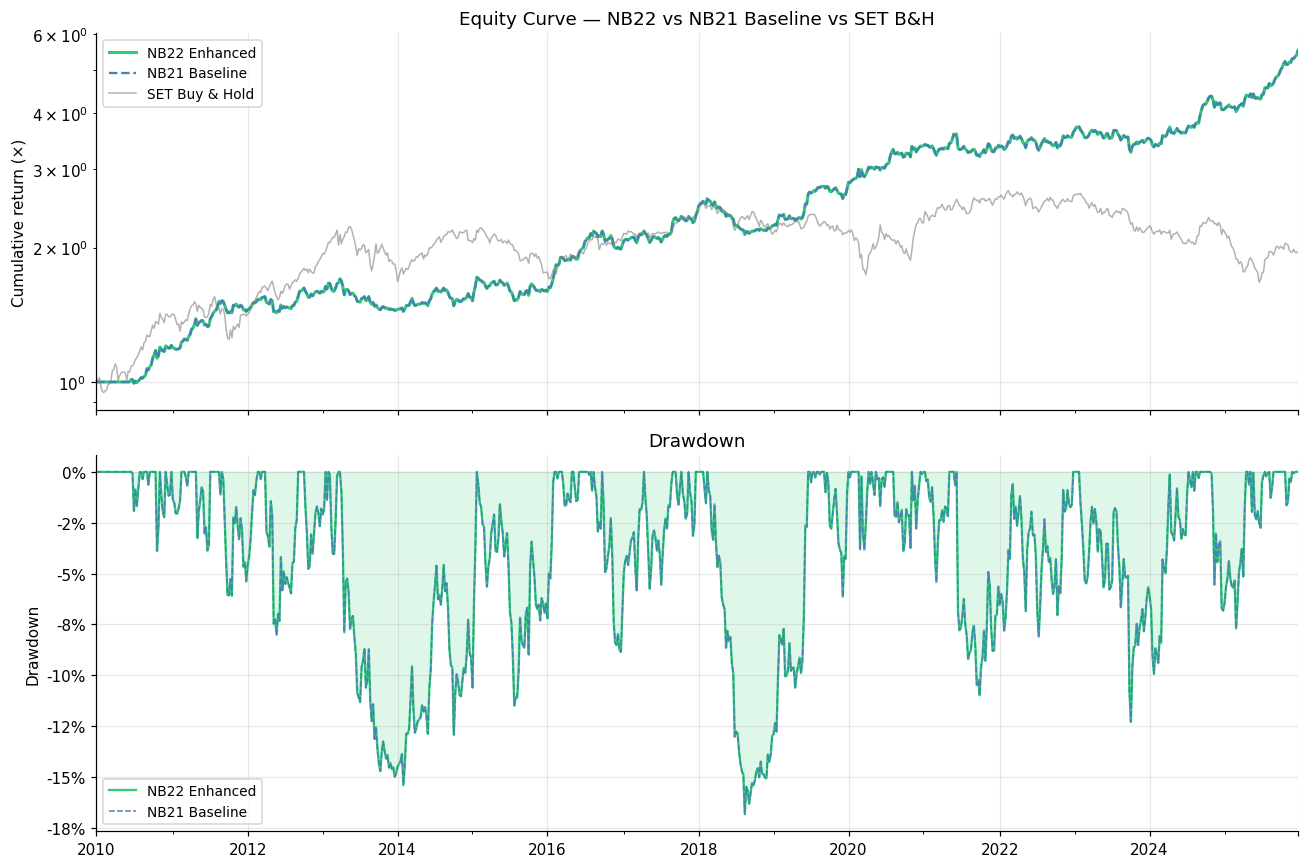

In [20]:
# ── Equity curve comparison ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

cum_baseline = (1 + baseline_ret.fillna(0)).cumprod()
cum_enhanced = (1 + enhanced_ret.fillna(0)).cumprod()
cum_set      = (1 + set_ret.fillna(0)).cumprod()

ax = axes[0]
cum_enhanced.plot(ax=ax, label='NB22 Enhanced',  color='#2ecc71', lw=2)
cum_baseline.plot(ax=ax, label='NB21 Baseline',   color='steelblue', lw=1.5, ls='--')
cum_set.plot(     ax=ax, label='SET Buy & Hold',  color='grey', lw=1, alpha=0.6)
ax.set_title('Equity Curve — NB22 vs NB21 Baseline vs SET B&H')
ax.set_ylabel('Cumulative return (×)')
ax.legend(fontsize=9)
ax.set_yscale('log')

# Drawdown
ax2 = axes[1]
dd_enh  = (cum_enhanced - cum_enhanced.expanding().max()) / cum_enhanced.expanding().max()
dd_base = (cum_baseline - cum_baseline.expanding().max()) / cum_baseline.expanding().max()
dd_enh.plot( ax=ax2, label='NB22 Enhanced',  color='#2ecc71', lw=1.5)
dd_base.plot(ax=ax2, label='NB21 Baseline',  color='steelblue', lw=1, ls='--')
ax2.fill_between(dd_enh.index, dd_enh, 0, alpha=0.15, color='#2ecc71')
ax2.set_title('Drawdown')
ax2.set_ylabel('Drawdown')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGS / 'nb22_equity_curve.png', bbox_inches='tight')
plt.show()

## 7. Summary


In [21]:
summary = {
    'SET Buy & Hold':  {'Sharpe': sharpe(set_ret),      'MaxDD': max_dd(set_ret),      'Calmar': calmar(set_ret)},
    'NB21 Baseline':   {'Sharpe': sharpe(baseline_ret), 'MaxDD': max_dd(baseline_ret), 'Calmar': calmar(baseline_ret)},
    'NB22 Enhanced':   {'Sharpe': sharpe(enhanced_ret), 'MaxDD': max_dd(enhanced_ret), 'Calmar': calmar(enhanced_ret)},
}

summary_df = pd.DataFrame(summary).T
summary_df['MaxDD'] = summary_df['MaxDD'].map('{:.1%}'.format)
summary_df['Sharpe'] = summary_df['Sharpe'].map('{:.3f}'.format)
summary_df['Calmar'] = summary_df['Calmar'].map('{:.2f}'.format)
print(summary_df.to_string())

print()
print('Signals used:', list(sig_keep.keys()) if sig_keep else 'none (no signal met threshold)')
if ic_results:
    sig_ic = [(r['label'], r['IC'], r['p'], r['stars']) for r in ic_results]
    print('IC results:')
    for label, ic, p, stars in sorted(sig_ic, key=lambda x: -abs(x[1])):
        print(f'  {label:40s}  IC={ic:+.4f}  p={p:.3f} {stars}')

               Sharpe   MaxDD Calmar
SET Buy & Hold  0.224  -37.7%   0.14
NB21 Baseline   0.872  -16.8%   0.69
NB22 Enhanced   0.872  -16.8%   0.69

Signals used: none (no signal met threshold)
